# CH-SIMS — RAW DATASET → EDA → 3-MODALITY FEATURES → FINAL PICKLE

**Fixed version.** Text = BERT (Chinese), Audio = openSMILE eGeMAPSv02, Visual = ResNet18.

| Problem | Fix |
|---|---|
| IDs were built from `video_id` only (repeats for many clips) and from file stems (`0001`) → **0 matches, nothing processed** | Unique ID `videoNumber_clipNumber`, files matched by parsing numbers from folder + file name |
| Text was searched in `.txt` files, but CH-SIMS text is the `text` column of the label file | Text read from the label file |
| Audio was searched as `.wav`; in CH-SIMS audio is **inside the .mp4** | Audio extracted with ffmpeg (16 kHz mono) |
| `bert-base-uncased` (English) used for Chinese text | `bert-base-chinese` |
| Label column auto-detected as `sentiment` (string) | Numeric `label_M` used as label |
| openSMILE vector cut to 74 of 88 features; random untrained 512→35 projection on ResNet | Native 88-d audio, native 512-d visual |
| `try/except` returned zero vectors silently and flags said "loaded" | No silent failures: failures are counted, printed and stored as `None` |
| Chinese word count used `split()` (always 1) | Character length |

Flow: `setup → discover raw files → columns/shapes/types/stats → ID matching → EDA → audio extraction → BERT / openSMILE / ResNet18 → final pickle → sanity check`

## 0. Install packages and mount Drive

In [ ]:
# Run once per Colab session (takes ~1 min). ffmpeg is already present on Colab.
!pip -q install opensmile transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 13.7 MB/s eta 0:00:00


In [ ]:
import os, shutil

# Remove the fake local folder, but ONLY if it is not a real Drive mount.
if os.path.isdir("/content/drive") and not os.path.ismount("/content/drive"):
    shutil.rmtree("/content/drive")
    print("Removed the fake local /content/drive folder.")

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os, sys, json, pickle, warnings, re, glob, subprocess, shutil
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
except ImportError:
    drive = None
    print("google.colab cannot be imported -> this kernel is NOT Google Colab.")

if drive is not None:
    try:
        drive.mount("/content/drive")      # approve the pop-up
    except Exception as e:
        print("Drive mount FAILED with:", repr(e))   # the real reason
        raise

DRIVE_ROOT = Path(os.environ.get("MPLMM_DRIVE_ROOT", "/content/drive/MyDrive"))
# Not on Colab? Uncomment and edit this line to the folder that CONTAINS CH-SIMS/:
# DRIVE_ROOT = Path("/path/to/folder/containing/CH-SIMS")

# Stop before creating folders. mkdir on an unmounted Colab creates a fake local MyDrive.
IN_COLAB = "google.colab" in sys.modules
if not DRIVE_ROOT.exists() or (IN_COLAB and not os.path.ismount("/content/drive")):
    raise RuntimeError("Google Drive is NOT mounted. Run this cell again, approve the pop-up, "
                       "wait for 'Mounted at /content/drive'. If it keeps failing: "
                       "Runtime > Restart session, then re-run.")

DELIV_ROOT = DRIVE_ROOT / "mplmm_final_deliverables"
DELIV_ROOT.mkdir(parents=True, exist_ok=True)
print("Deliverables root:", DELIV_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Deliverables root: /content/drive/MyDrive/mplmm_final_deliverables


## 1. Configuration (paths are the same as before — raw files are never modified)

In [ ]:
DATASET_NAME = "CH-SIMS"
DATASET_ROOT = DRIVE_ROOT / "CH-SIMS"
RAW_ROOT     = DATASET_ROOT / "Raw"

OUT_ROOT      = DELIV_ROOT / "outputs" / "CH-SIMS"
FIG_ROOT      = OUT_ROOT / "figures"
TABLE_ROOT    = OUT_ROOT / "tables"
ARTIFACT_ROOT = OUT_ROOT / "artifacts"
CACHE_ROOT    = ARTIFACT_ROOT / "cache"          # resumable feature cache (survives Colab disconnects)
for p in [OUT_ROOT, FIG_ROOT, TABLE_ROOT, ARTIFACT_ROOT, CACHE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

WAV_DIR = Path(os.environ.get("MPLMM_WAV_DIR", "/content/chsims_wav"))   # local disk = fast; re-created if lost
WAV_DIR.mkdir(parents=True, exist_ok=True)

# ---- feature settings ----
TEXT_MODEL      = "bert-base-chinese"   # CH-SIMS is Chinese. For MOSI / MOSEI use "bert-base-uncased".
MAX_TEXT_LEN    = 64
N_FRAMES        = 5                     # frames sampled per clip for ResNet18
FORCE_RECOMPUTE = False                 # True = ignore cached features and recompute everything
RUN_FEATURES    = True                  # False = only inspect + EDA

assert RAW_ROOT.exists(), f"RAW_ROOT not found: {RAW_ROOT}  (check the folder name/case in Drive)"
print("Dataset root:", DATASET_ROOT)
print("Raw root    :", RAW_ROOT)

Dataset root: /content/drive/MyDrive/CH-SIMS
Raw root    : /content/drive/MyDrive/CH-SIMS/Raw


## 2. Discover the raw files
Reports the real folder structure first, so any layout surprise is visible immediately.

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display

VIDEO_EXT = {".mp4", ".avi", ".mov", ".mkv", ".webm"}
AUDIO_EXT = {".wav", ".flac", ".mp3", ".m4a"}

files = sorted(p for p in RAW_ROOT.rglob("*") if p.is_file())
print("Total raw files:", len(files))
ext_counts = pd.Series([p.suffix.lower() or "<none>" for p in files]).value_counts().rename("count").to_frame()
display(ext_counts)

print("\nExample paths (relative to Raw/):")
for ext in ext_counts.index[:4]:
    for p in [q for q in files if (q.suffix.lower() or "<none>") == ext][:3]:
        print(f"  {ext:6s} {p.relative_to(RAW_ROOT)}")

VIDEO_FILES = [p for p in files if p.suffix.lower() in VIDEO_EXT]
AUDIO_FILES = [p for p in files if p.suffix.lower() in AUDIO_EXT]
print(f"\nVideo files: {len(VIDEO_FILES)} | separate audio files: {len(AUDIO_FILES)}")
if not AUDIO_FILES:
    print("-> No separate audio files: audio will be extracted from the videos (section 7).")

Total raw files: 4047


,count
.mp4,4047



Example paths (relative to Raw/):
  .mp4   video_0001/0001.mp4
  .mp4   video_0001/0002.mp4
  .mp4   video_0001/0003.mp4

Video files: 4047 | separate audio files: 0
-> No separate audio files: audio will be extracted from the videos (section 7).


## 3. Raw label file — columns, shapes, types and basic statistics

In [ ]:
cands = [DATASET_ROOT / "label.csv"] + sorted(
    p for p in DATASET_ROOT.rglob("*")
    if p.suffix.lower() in {".csv", ".tsv", ".xlsx"} and "label" in p.name.lower())
label_file = next((p for p in cands if p.exists()), None)
assert label_file is not None, "No label file found under CH-SIMS/. Set label_file manually."

# CH-SIMS label.csv is delivered WITHOUT a header row. If we let pandas guess, the first sample becomes the
# column names (2280 rows, columns like '-1.0.1'). So we detect that case and name the columns ourselves.
CHSIMS_COLUMNS = ["video_id", "clip_id", "text", "label_T", "label_A", "label_V", "label_M", "sentiment", "split"]
sep = "\t" if label_file.suffix.lower() == ".tsv" else ","

if label_file.suffix.lower() in {".csv", ".tsv"}:
    first_cell = str(pd.read_csv(label_file, header=None, nrows=1, sep=sep).iloc[0, 0]).strip()
    headerless = bool(re.match(r"^video_?\d+$", first_cell, flags=re.I))      # first cell looks like 'video_0001'
    if headerless:
        labels_df = pd.read_csv(label_file, header=None, sep=sep)
        assert labels_df.shape[1] == len(CHSIMS_COLUMNS), (
            f"Headerless label file has {labels_df.shape[1]} columns, expected {len(CHSIMS_COLUMNS)}: "
            f"{CHSIMS_COLUMNS}. Show me labels_df.head() and I will adapt the names.")
        labels_df.columns = CHSIMS_COLUMNS
        print("label.csv has NO header row -> column names assigned manually.")
    else:
        labels_df = pd.read_csv(label_file, sep=sep)
else:
    labels_df = pd.read_excel(label_file)

print("Label file:", label_file)
print("Shape     :", labels_df.shape)
print("Columns   :", list(labels_df.columns))
print("\n--- df.head() ---")
display(labels_df.head())
print("--- dtypes ---")
display(labels_df.dtypes.rename("dtype").to_frame())
print("--- missing values ---")
display(labels_df.isna().sum().rename("missing").to_frame())
print("--- describe (all columns) ---")
display(labels_df.describe(include="all").T)

# Required columns (clear error instead of silent wrong auto-detection)
for c in ["video_id", "clip_id", "text"]:
    assert c in labels_df.columns, f"Label file has no column {c!r}. Columns: {list(labels_df.columns)}"
LABEL_COLUMN = next((c for c in ["label_M", "label"] if c in labels_df.columns), None)
assert LABEL_COLUMN is not None, "No numeric label column (label_M / label) found."
SPLIT_COLUMN = next((c for c in ["split", "mode"] if c in labels_df.columns), None)
print("\nLabel column:", LABEL_COLUMN, "| split column:", SPLIT_COLUMN)

label.csv has NO header row -> column names assigned manually.
Label file: /content/drive/MyDrive/CH-SIMS/label.csv
Shape     : (2281, 9)
Columns   : ['video_id', 'clip_id', 'text', 'label_T', 'label_A', 'label_V', 'label_M', 'sentiment', 'split']

--- df.head() ---


,video_id,clip_id,text,label_T,label_A,label_V,label_M,sentiment,split
0,video_0001,1,我不想嫁给李茶,-1.0,-1.0,-1.0,-1.0,Negative,train
1,video_0001,2,你这是嫁入豪门啊！,1.0,1.0,0.8,1.0,Positive,train
2,video_0001,3,我不想嫁入什么豪门，我们不就是豪门吗？,-1.0,-0.8,-1.0,-1.0,Negative,test
3,video_0001,4,有那么明显吗？,-1.0,-0.6,-1.0,-1.0,Negative,train
4,video_0001,5,我在这消费这么多钱，我低血糖吃块糖还不行了,-1.0,-1.0,-1.0,-1.0,Negative,train


--- dtypes ---


,dtype
video_id,object
clip_id,int64
text,object
label_T,float64
label_A,float64
label_V,float64
label_M,float64
sentiment,object
split,object


--- missing values ---


,missing
video_id,0
clip_id,0
text,0
label_T,0
label_A,0
label_V,0
label_M,0
sentiment,0
split,0


--- describe (all columns) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,2281,60,video_0054,188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clip_id,2281.0,NaN,NaN,NaN,31.929417,32.474698,1.0,10.0,22.0,41.0,188.0
text,2281,2275,你怎么来了,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_T,2281.0,NaN,NaN,NaN,-0.193073,0.690922,-1.0,-1.0,-0.2,0.2,1.0
label_A,2281.0,NaN,NaN,NaN,-0.155546,0.621124,-1.0,-0.8,0.0,0.2,1.0
label_V,2281.0,NaN,NaN,NaN,-0.192722,0.637126,-1.0,-0.8,-0.2,0.2,1.0
label_M,2281.0,NaN,NaN,NaN,-0.150022,0.726293,-1.0,-1.0,-0.2,0.4,1.0
sentiment,2281,3,Negative,1238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,2281,3,train,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Label column: label_M | split column: split


## 4. Unique sample IDs and modality matching
`video_id` alone repeats for many clips, and file stems like `0001` repeat across folders. The key used here is
`<video number>_<clip number>` (e.g. `video_0001` + clip `1` → `1_1`), built identically from the label file and from the file paths.

In [ ]:
def vid_num(x):
    return int(re.findall(r"\d+", str(x))[-1])          # 'video_0001' -> 1

labels_df["sample_id"] = [f"{vid_num(v)}_{int(c)}" for v, c in zip(labels_df.video_id, labels_df.clip_id)]
assert labels_df.sample_id.is_unique, "sample_id is not unique - check video_id/clip_id columns"

def key_from_path(p: Path):
    # handles  video_0001/0001.mp4 , video_0001/1.mp4 , video_0001_1.mp4
    m = re.match(r"video_?(\d+)$", p.parent.name, flags=re.I)
    nums = re.findall(r"\d+", p.stem)
    if m and nums:
        return f"{int(m.group(1))}_{int(nums[-1])}"
    if len(nums) >= 2:
        return f"{int(nums[0])}_{int(nums[1])}"
    return None

video_map, dup, unparsed = {}, 0, []
for p in VIDEO_FILES:
    k = key_from_path(p)
    if k is None: unparsed.append(p); continue
    if k in video_map: dup += 1
    video_map[k] = p

audio_map = {}
for p in AUDIO_FILES:
    k = key_from_path(p)
    if k is not None: audio_map[k] = p          # only used if real audio files exist

text_map  = dict(zip(labels_df.sample_id, labels_df.text.astype(str)))
label_map = dict(zip(labels_df.sample_id, labels_df[LABEL_COLUMN]))

print(f"label ids: {len(label_map)} | video keys: {len(video_map)} | duplicate video keys: {dup} | unparsed paths: {len(unparsed)}")
print("example label keys:", list(label_map)[:3], "| example video keys:", list(video_map)[:3])
overlap = set(video_map) & set(label_map)
print("video <-> label overlap:", len(overlap))

# Why are there more video files than labels? Report it instead of guessing.
extra_videos   = sorted(set(video_map) - set(label_map), key=lambda k: tuple(map(int, k.split("_"))))
labels_no_file = sorted(set(label_map) - set(video_map), key=lambda k: tuple(map(int, k.split("_"))))
print(f"video files with NO label row : {len(extra_videos)}  (ignored - unlabeled clips)  e.g. {extra_videos[:5]}")
print(f"label rows with NO video file : {len(labels_no_file)}  e.g. {labels_no_file[:5]}")
print(f"video folders on disk: {len({k.split('_')[0] for k in video_map})} | folders in label file: {labels_df.video_id.nunique()}")
print(f"raw .mp4 files: {len(VIDEO_FILES)} | parsed keys: {len(video_map)} | duplicates overwritten: {dup} | unparsed: {len(unparsed)}")
if len(VIDEO_FILES) != len(video_map) + dup + len(unparsed):
    print("WARNING: counts do not add up - show me this output.")
assert len(overlap) > 0, ("No overlap between labels and videos. Send 5 example paths from Raw/ "
                          "and adapt key_from_path().")

labels_df["has_text"]  = labels_df.text.astype(str).str.strip().ne("")
labels_df["has_video"] = labels_df.sample_id.isin(video_map)
labels_df["has_audio"] = labels_df.sample_id.isin(audio_map) | labels_df.has_video   # audio extractable from video
print("\nSamples per modality:", labels_df[["has_text", "has_audio", "has_video"]].sum().to_dict())

label ids: 2281 | video keys: 2281 | duplicate video keys: 1766 | unparsed paths: 0
example label keys: ['1_1', '1_2', '1_3'] | example video keys: ['1_1', '1_2', '1_3']
video <-> label overlap: 2281
video files with NO label row : 0  (ignored - unlabeled clips)  e.g. []
label rows with NO video file : 0  e.g. []
video folders on disk: 60 | folders in label file: 60
raw .mp4 files: 4047 | parsed keys: 2281 | duplicates overwritten: 1766 | unparsed: 0

Samples per modality: {'has_text': 2281, 'has_audio': 2281, 'has_video': 2281}


## 5. Basic EDA on the raw dataset

,count,percent
sentiment,,
Negative,1238,54.27
Positive,698,30.60
Neutral,345,15.12


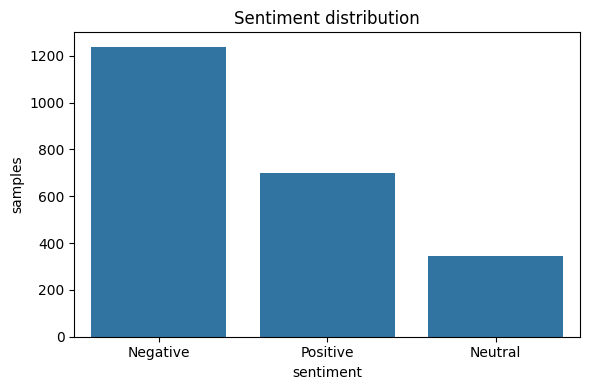

,count
split,
train,1368
test,457
valid,456


sentiment,Negative,Neutral,Positive
split,,,
test,248,69,140
train,742,207,419
valid,248,69,139


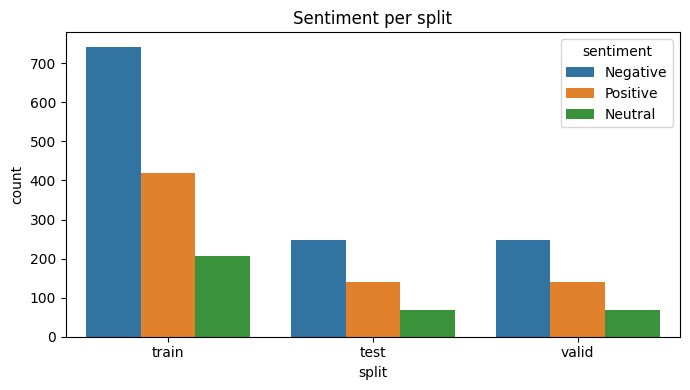

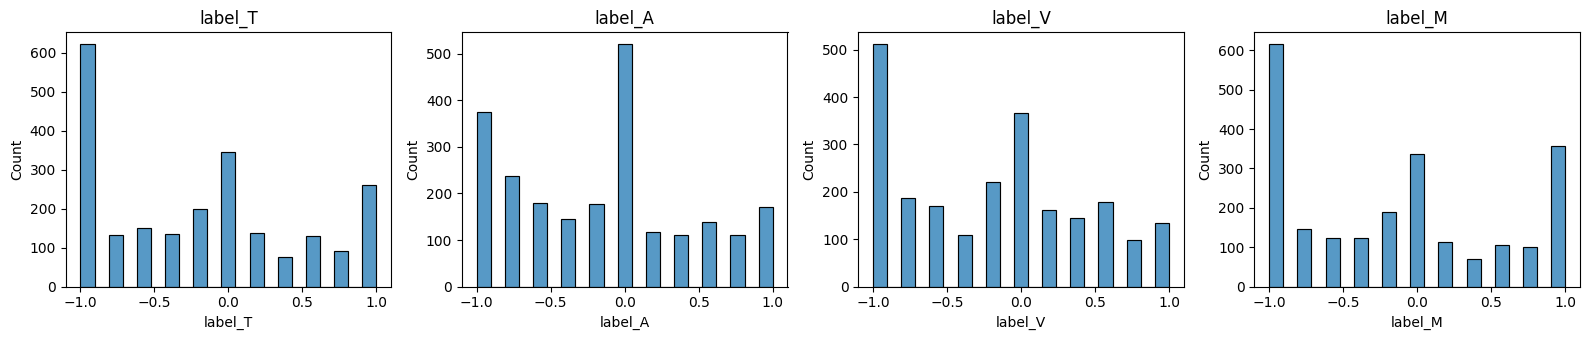

,label_T,label_A,label_V,label_M
label_T,1.000,0.717,0.845,0.830
label_A,0.717,1.000,0.643,0.498
label_V,0.845,0.643,1.000,0.778
label_M,0.830,0.498,0.778,1.000


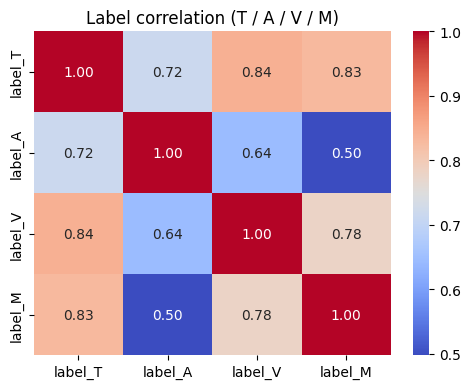

,text_char_len
count,2281.000000
mean,15.849627
std,7.321365
min,1.000000
25%,10.000000
50%,15.000000
75%,20.000000
max,47.000000


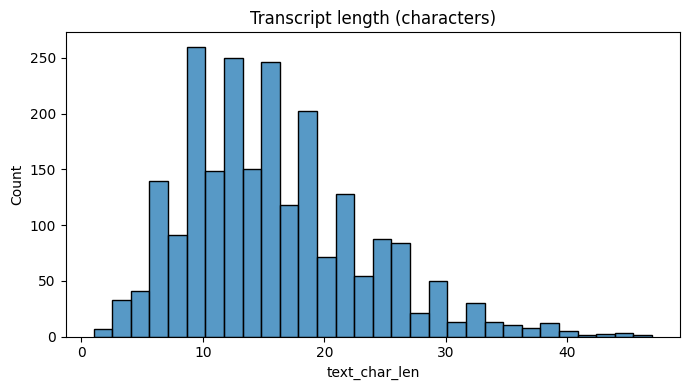

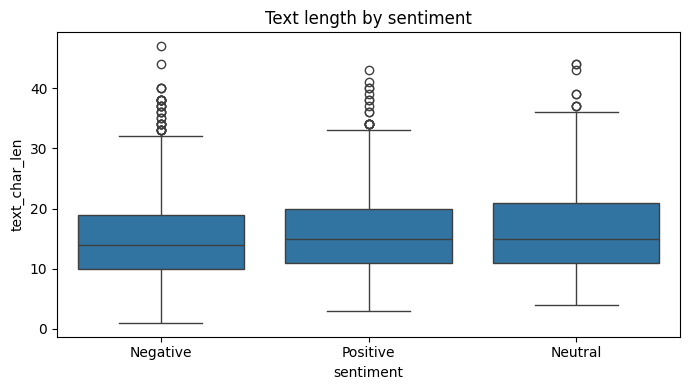

,modality,samples
0,Text,2281
1,Audio,2281
2,Video,2281


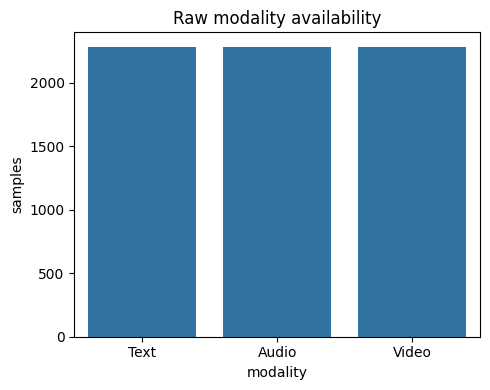

Complete 3-modality samples: 2281 / 2281


In [ ]:
# --- sentiment class (use the file's own column if present, otherwise derive from label_M) ---
if "sentiment" not in labels_df.columns:
    labels_df["sentiment"] = np.where(labels_df[LABEL_COLUMN] < 0, "Negative",
                              np.where(labels_df[LABEL_COLUMN] > 0, "Positive", "Neutral"))
if SPLIT_COLUMN and SPLIT_COLUMN != "split":
    labels_df["split"] = labels_df[SPLIT_COLUMN]
if "split" in labels_df.columns:
    labels_df["split"] = labels_df["split"].astype(str).str.lower().replace({"val": "valid", "validation": "valid"})

labels_df["text_char_len"] = labels_df.text.astype(str).str.len()    # Chinese: characters, not words
LABEL_COLS = [c for c in ["label_T", "label_A", "label_V", "label_M", "label"] if c in labels_df.columns]

def savefig(name):
    plt.tight_layout(); plt.savefig(FIG_ROOT / name, dpi=160, bbox_inches="tight"); plt.show()

# 1) sentiment distribution
vc = labels_df.sentiment.value_counts()
display(pd.DataFrame({"count": vc, "percent": (vc / vc.sum() * 100).round(2)}))
fig, ax = plt.subplots(figsize=(6, 4)); sns.barplot(x=vc.index, y=vc.values, ax=ax)
ax.set_title("Sentiment distribution"); ax.set_ylabel("samples"); savefig("01_sentiment_distribution.png")

# 2) split distribution (+ sentiment per split)
if "split" in labels_df.columns:
    display(labels_df.split.value_counts().to_frame("count"))
    display(pd.crosstab(labels_df.split, labels_df.sentiment))
    fig, ax = plt.subplots(figsize=(7, 4)); sns.countplot(data=labels_df, x="split", hue="sentiment", ax=ax)
    ax.set_title("Sentiment per split"); savefig("02_sentiment_by_split.png")

# 3) numeric label distributions + correlation
fig, axes = plt.subplots(1, len(LABEL_COLS), figsize=(4 * len(LABEL_COLS), 3.5), squeeze=False)
for ax, c in zip(axes[0], LABEL_COLS):
    sns.histplot(labels_df[c], bins=21, ax=ax); ax.set_title(c)
savefig("03_label_distributions.png")
if len(LABEL_COLS) > 1:
    corr = labels_df[LABEL_COLS].corr(); display(corr.round(3))
    fig, ax = plt.subplots(figsize=(5, 4)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
    ax.set_title("Label correlation (T / A / V / M)"); savefig("04_label_correlation.png")
    corr.to_csv(TABLE_ROOT / "label_correlation.csv")

# 4) text length (characters)
display(labels_df.text_char_len.describe().to_frame())
fig, ax = plt.subplots(figsize=(7, 4)); sns.histplot(labels_df.text_char_len, bins=30, ax=ax)
ax.set_title("Transcript length (characters)"); savefig("05_text_char_length.png")
fig, ax = plt.subplots(figsize=(7, 4)); sns.boxplot(data=labels_df, x="sentiment", y="text_char_len", ax=ax)
ax.set_title("Text length by sentiment"); savefig("06_text_length_by_sentiment.png")

# 5) modality availability (from raw files)
avail = pd.DataFrame({"modality": ["Text", "Audio", "Video"],
                      "samples": [labels_df.has_text.sum(), labels_df.has_audio.sum(), labels_df.has_video.sum()]})
display(avail)
fig, ax = plt.subplots(figsize=(5, 4)); sns.barplot(data=avail, x="modality", y="samples", ax=ax)
ax.set_title("Raw modality availability"); savefig("07_modality_availability.png")
labels_df["complete_3modal"] = labels_df[["has_text", "has_audio", "has_video"]].all(axis=1)
print("Complete 3-modality samples:", int(labels_df.complete_3modal.sum()), "/", len(labels_df))

# save tables
labels_df.drop(columns=[]).to_csv(TABLE_ROOT / "chsims_raw_eda_dataframe.csv", index=False)
vc.to_csv(TABLE_ROOT / "sentiment_distribution.csv"); avail.to_csv(TABLE_ROOT / "modality_availability.csv", index=False)
labels_df[LABEL_COLS].describe().T.to_csv(TABLE_ROOT / "label_statistics.csv")

## 6. Feature extraction setup
Features are **cached to Drive** after each modality, so a Colab disconnect does not lose hours of work. Set `FORCE_RECOMPUTE=True` to redo them.

In [ ]:
if not RUN_FEATURES:
    raise SystemExit("RUN_FEATURES=False -> stopped after EDA.")

import torch, torch.nn as nn
from tqdm.auto import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "(switch Runtime -> GPU for much faster BERT/ResNet)")

ids = [k for k in labels_df.sample_id if k in video_map]      # samples that have a video (and hence audio)
print("Samples to process:", len(ids))
FAILS = {"text": [], "audio": [], "visual": []}

def cached(name, fn):
    p = CACHE_ROOT / f"{name}.pkl"
    if p.exists() and not FORCE_RECOMPUTE:
        print(f"[cache] loaded {p.name}")
        return pickle.load(open(p, "rb"))
    out = fn()
    pickle.dump(out, open(p, "wb"), protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[cache] saved  {p.name}")
    return out

Device: cuda (switch Runtime -> GPU for much faster BERT/ResNet)
Samples to process: 2281


## 7. Audio extraction (audio lives inside the .mp4 files)

In [21]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def _one(k):
    if k in audio_map:
        return k, audio_map[k], None
    out = WAV_DIR / f"{k}.wav"
    if out.exists() and out.stat().st_size > 1000:          # already converted -> skip
        return k, out, None
    tmp = WAV_DIR / f"{k}.tmp.wav"
    r = subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(video_map[k]),
                        "-vn", "-ac", "1", "-ar", "16000", str(tmp)],
                       capture_output=True, text=True)
    if r.returncode != 0 or not tmp.exists():
        return k, None, r.stderr[:200]
    tmp.rename(out)       # a half-written file (disconnect mid-write) is never mistaken for a finished one
    return k, out, None

def make_wavs(workers=8):
    out_map, errors = {}, []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(_one, k) for k in ids]
        for f in tqdm(as_completed(futs), total=len(futs), desc="ffmpeg -> wav"):
            k, path, err = f.result()
            if path is not None: out_map[k] = path
            else: errors.append((k, err))
    print(f"wav ready: {len(out_map)} | ffmpeg failures: {len(errors)}")
    for k, e in errors[:3]: print("ffmpeg failed:", video_map[k], "|", e)
    return out_map

wav_map = make_wavs()

ffmpeg -> wav:   0%|          | 0/2281 [00:00<?, ?it/s]

wav ready: 2281 | ffmpeg failures: 0


## 8. TEXT — BERT (CLS embedding, 768-d)

In [ ]:
def run_bert():
    from transformers import AutoTokenizer, AutoModel
    tok  = AutoTokenizer.from_pretrained(TEXT_MODEL)
    bert = AutoModel.from_pretrained(TEXT_MODEL).to(device).eval()
    feats = {}
    for i in tqdm(range(0, len(ids), 32), desc=f"BERT ({TEXT_MODEL})"):
        batch = ids[i:i + 32]
        try:
            enc = tok([text_map[k] for k in batch], return_tensors="pt", truncation=True,
                      max_length=MAX_TEXT_LEN, padding=True).to(device)
            with torch.no_grad():
                cls = bert(**enc).last_hidden_state[:, 0, :].cpu().numpy().astype(np.float32)
            for k, v in zip(batch, cls): feats[k] = v
        except Exception as e:
            for k in batch: FAILS["text"].append((k, repr(e)))
    del bert
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return feats

text_feat = cached("text_bert", run_bert)
print("text features:", len(text_feat), "| dim:", next(iter(text_feat.values())).shape, "| failures:", len(FAILS["text"]))

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  412MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT (bert-base-chinese):   0%|          | 0/72 [00:00<?, ?it/s]

[cache] saved  text_bert.pkl
text features: 2281 | dim: (768,) | failures: 0


## 9. AUDIO — openSMILE eGeMAPSv02 functionals (88-d)

In [22]:
def run_opensmile():
    import opensmile
    smile = opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02,
                            feature_level=opensmile.FeatureLevel.Functionals)
    feats = {}
    for k in tqdm(ids, desc="openSMILE"):
        if k not in wav_map: continue
        try:
            feats[k] = smile.process_file(str(wav_map[k])).values[0].astype(np.float32)
        except Exception as e:
            FAILS["audio"].append((k, repr(e)))
    return feats

audio_feat = cached("audio_opensmile", run_opensmile)
print("audio features:", len(audio_feat), "| dim:", next(iter(audio_feat.values())).shape, "| failures:", len(FAILS["audio"]))
print("first failures:", FAILS["audio"][:3])

openSMILE:   0%|          | 0/2281 [00:00<?, ?it/s]

[cache] saved  audio_opensmile.pkl
audio features: 2281 | dim: (88,) | failures: 0
first failures: []


## 10. VISUAL — ResNet18 (avg-pool, 512-d, mean over sampled frames)

In [23]:
def run_resnet():
    import cv2
    from PIL import Image
    import torchvision.models as tvm
    w = tvm.ResNet18_Weights.DEFAULT
    resnet = nn.Sequential(*list(tvm.resnet18(weights=w).children())[:-1]).to(device).eval()
    tf = w.transforms()

    def vec(path):
        cap = cv2.VideoCapture(str(path))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release(); raise RuntimeError("video has 0 frames")
        frames = []
        for idx in np.linspace(0, total - 1, min(N_FRAMES, total), dtype=int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx)); ok, fr = cap.read()
            if ok: frames.append(tf(Image.fromarray(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))))   # PIL image (numpy would fail)
        cap.release()
        if not frames: raise RuntimeError("no frame could be decoded")
        with torch.no_grad():
            return resnet(torch.stack(frames).to(device)).flatten(1).mean(0).cpu().numpy().astype(np.float32)

    feats = {}
    for k in tqdm(ids, desc="ResNet18"):
        try:
            feats[k] = vec(video_map[k])
        except Exception as e:
            FAILS["visual"].append((k, repr(e)))
    return feats

visual_feat = cached("visual_resnet18", run_resnet)
print("visual features:", len(visual_feat), "| dim:", next(iter(visual_feat.values())).shape, "| failures:", len(FAILS["visual"]))
print("first failures:", FAILS["visual"][:3])

ResNet18:   0%|          | 0/2281 [00:00<?, ?it/s]

[cache] saved  visual_resnet18.pkl
visual features: 2281 | dim: (512,) | failures: 0
first failures: []


## 11. Final pickle
Two views of the same data are stored:
* `samples` – one dict per clip (missing modality = `None`, never fake zeros) with flags.
* `train` / `valid` / `test` – stacked arrays of **complete 3-modality samples** only (`text`, `audio`, `vision`, `labels`, `ids`, `raw_text`).

In [24]:
lab = labels_df.set_index("sample_id")
rows = []
for k in labels_df.sample_id:
    r = lab.loc[k]
    rows.append({
        "id": k, "video_id": r.video_id, "clip_id": int(r.clip_id),
        "text": text_feat.get(k), "acoustic": audio_feat.get(k), "visual": visual_feat.get(k),
        "label": float(r[LABEL_COLUMN]), "sentiment": r.sentiment,
        "split": r["split"] if "split" in lab.columns else None, "raw_text": text_map[k],
        "has_text": k in text_feat, "has_acoustic": k in audio_feat, "has_visual": k in visual_feat,
    })
df = pd.DataFrame(rows)
df["complete"] = df[["has_text", "has_acoustic", "has_visual"]].all(axis=1)

def stack_split(d):
    d = d[d.complete]
    return {
        "text":   np.stack(d.text.values).astype(np.float32),        # (N, 768)
        "audio":  np.stack(d.acoustic.values).astype(np.float32),    # (N, 88)
        "vision": np.stack(d.visual.values).astype(np.float32),      # (N, 512)
        "labels": d.label.values.astype(np.float32),                 # (N,)  regression label_M
        "ids":    d.id.tolist(), "raw_text": d.raw_text.tolist(),
        "sentiment": d.sentiment.tolist(),
    }

payload = {
    "dataset": DATASET_NAME,
    "feature_reference": {"text": f"{TEXT_MODEL} CLS (768)",
                          "acoustic": "openSMILE eGeMAPSv02 functionals (88)",
                          "visual": f"ResNet18 avgpool, mean of {N_FRAMES} frames (512)"},
    "label_definition": f"{LABEL_COLUMN}: continuous sentiment in [-1, 1]; sentiment column = Negative(<0) / Neutral(0) / Positive(>0)",
    "samples": rows,
}
if "split" in df.columns and df.split.notna().any():
    for s in ["train", "valid", "test"]:
        part = df[df.split == s]
        if len(part) and part.complete.any():
            payload[s] = stack_split(part)
else:
    payload["all"] = stack_split(df)

pkl = ARTIFACT_ROOT / "ch_sims_raw_features.pkl"
with open(pkl, "wb") as f: pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
print("Saved:", pkl, f"({pkl.stat().st_size/1024**2:.1f} MB)")
if (~df.complete).any():
    print(f"NOTE: {(~df.complete).sum()} samples lack a modality and are excluded from the train/valid/test arrays "
          "(they remain in 'samples' with None).")

Saved: /content/drive/MyDrive/mplmm_final_deliverables/outputs/CH-SIMS/artifacts/ch_sims_raw_features.pkl (24.3 MB)


## 12. Sanity check — reload the pickle, shapes, dtypes, statistics, zero-vector check

In [27]:
with open(pkl, "rb") as f: chk = pickle.load(f)

print("Top-level keys:", list(chk.keys()))
rows_chk = []
for s in ["train", "valid", "test", "all"]:
    if s in chk:
        d = chk[s]
        rows_chk.append({"split": s, "N": len(d["labels"]),
                         "text": d["text"].shape, "audio": d["audio"].shape, "vision": d["vision"].shape,
                         "dtype": str(d["text"].dtype),
                         "labels": f"{d['labels'].min():.1f}..{d['labels'].max():.1f}"})
summary = pd.DataFrame(rows_chk); display(summary)

print("\nPer-modality statistics over all complete samples:")
stat_rows = []
for m in ["text", "audio", "vision"]:
    arr = np.concatenate([chk[s][m] for s in ["train", "valid", "test", "all"] if s in chk])
    stat_rows.append({"modality": m, "shape": arr.shape, "mean": arr.mean(), "std": arr.std(),
                      "min": arr.min(), "max": arr.max(),
                      "nan": int(np.isnan(arr).sum()),
                      "all_zero_rows": int((np.abs(arr).sum(1) == 0).sum())})
stats = pd.DataFrame(stat_rows); display(stats)
assert stats.all_zero_rows.sum() == 0 and stats.nan.sum() == 0, "zero/NaN features found - inspect FAILS"

print("\n--- final dataframe head ---")
display(df[["id", "raw_text", "label", "sentiment", "split", "has_text", "has_acoustic", "has_visual", "complete"]].head())
print("Complete 3-modality:", int(df.complete.sum()), "/", len(df))

summary.to_csv(TABLE_ROOT / "final_feature_summary.csv", index=False)
stats.to_csv(TABLE_ROOT / "final_feature_stats.csv", index=False)
json.dump({"failures": {k: len(v) for k, v in FAILS.items()}, "pickle": str(pkl)},
          open(OUT_ROOT / "run_summary.json", "w"), indent=2)
print("\nDONE. Pickle:", pkl)

Top-level keys: ['dataset', 'feature_reference', 'label_definition', 'samples', 'train', 'valid', 'test']


,split,N,text,audio,vision,dtype,labels
0,train,1368,"(1368, 768)","(1368, 88)","(1368, 512)",float32,-1.0..1.0
1,valid,456,"(456, 768)","(456, 88)","(456, 512)",float32,-1.0..1.0
2,test,457,"(457, 768)","(457, 88)","(457, 512)",float32,-1.0..1.0



Per-modality statistics over all complete samples:


,modality,shape,mean,std,min,max,nan,all_zero_rows
0,text,"(2281, 768)",-0.005632,0.791312,-6.805656,11.772645,0,0
1,audio,"(2281, 88)",100.897972,429.248077,-9535.586914,63619.070312,0,0
2,vision,"(2281, 512)",0.713482,0.647894,0.000000,11.564506,0,0



--- final dataframe head ---


,id,raw_text,label,sentiment,split,has_text,has_acoustic,has_visual,complete
0,1_1,我不想嫁给李茶,-1.0,Negative,train,True,True,True,True
1,1_2,你这是嫁入豪门啊！,1.0,Positive,train,True,True,True,True
2,1_3,我不想嫁入什么豪门，我们不就是豪门吗？,-1.0,Negative,test,True,True,True,True
3,1_4,有那么明显吗？,-1.0,Negative,train,True,True,True,True
4,1_5,我在这消费这么多钱，我低血糖吃块糖还不行了,-1.0,Negative,train,True,True,True,True


Complete 3-modality: 2281 / 2281

DONE. Pickle: /content/drive/MyDrive/mplmm_final_deliverables/outputs/CH-SIMS/artifacts/ch_sims_raw_features.pkl
